
# Financial & Operational Risk Detection in Utility Infrastructure
## Anomaly Detection in High-Frequency Energy Data: A Statistical Quality Assurance Framework for Operational Risk

This project analyzes high-frequency household electricity consumption data to detect operational anomalies and build a predictive quality-assurance workflow. From a utility perspective, the goal is to identify meter errors, suspicious usage, or unstable load behavior before they become operational risks. From a financial-services perspective, the same workflow mirrors exception monitoring in KYC and controls testing, where analysts screen large volumes of records to isolate high-risk cases for review.

The notebook follows a complete machine learning pipeline:

1. Data preprocessing and quality assurance
2. Exploratory data analysis with stakeholder-friendly visualizations
3. Isolation Forest for anomaly detection
4. Random Forest Regressor for predictive load modeling
5. Business interpretation, model evaluation, and improvement opportunities



## 1. Imports


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.ensemble import IsolationForest, RandomForestRegressor
from sklearn.metrics import precision_score, recall_score, f1_score, r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", None)

candidate_paths = [
    Path("household_power_consumption.txt"),
    Path("final1") / "household_power_consumption.txt",
    Path.cwd() / "household_power_consumption.txt",
    Path.cwd() / "final1" / "household_power_consumption.txt",
]
DATA_PATH = next((path for path in candidate_paths if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Could not find household_power_consumption.txt in the notebook folder or the project root.")

RANDOM_STATE = 42



## 2. Load the Raw Text File
The dataset is stored as a semicolon-delimited text file, so the first quality-assurance step is to read the raw strings correctly and inspect missing values before modeling.


In [2]:

raw_df = pd.read_csv(DATA_PATH, sep=';', na_values='?')
raw_df.head()


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [3]:

missing_summary = raw_df.isna().sum().sort_values(ascending=False).to_frame('missing_values')
missing_summary['missing_pct'] = (missing_summary['missing_values'] / len(raw_df) * 100).round(2)

print(f"Rows: {len(raw_df):,}")
print(f"Columns: {raw_df.shape[1]}")
print(f"Rows containing at least one missing value: {raw_df.isna().any(axis=1).sum():,}")
missing_summary


Rows: 2,075,259
Columns: 9
Rows containing at least one missing value: 25,979


,missing_values,missing_pct
Global_active_power,25979,1.25
Sub_metering_2,25979,1.25
Global_reactive_power,25979,1.25
Voltage,25979,1.25
Global_intensity,25979,1.25
Sub_metering_3,25979,1.25
Sub_metering_1,25979,1.25
Date,0,0.00
Time,0,0.00



## 3. Preprocessing and Data Quality Rationale

### Why linear interpolation instead of deleting rows?
Deleting rows would remove thousands of time points from a continuous sensor stream and break the temporal structure that matters in energy analytics. In a utility or controls environment, those missing values are usually short measurement gaps rather than true zero usage. Linear interpolation is appropriate here because:

- it preserves the time-series continuity needed for trend and anomaly analysis,
- it estimates missing points from nearby observations rather than inventing unrelated values,
- it avoids biasing the dataset toward periods with perfect sensor quality.

After imputation, I also create two business-facing features:

- `Is_Weekend`: identifies demand-pattern changes on Saturdays and Sundays.
- `Time_of_Day`: groups each reading into `Night`, `Morning`, `Afternoon`, or `Evening` so results can be explained more clearly to non-technical stakeholders.


In [4]:

power_df = raw_df.copy()
power_df['Datetime'] = pd.to_datetime(
    power_df['Date'] + ' ' + power_df['Time'],
    format='%d/%m/%Y %H:%M:%S'
)

power_df = power_df.drop(columns=['Date', 'Time']).set_index('Datetime').sort_index()

numeric_cols = power_df.columns.tolist()
power_df[numeric_cols] = power_df[numeric_cols].interpolate(method='time').ffill().bfill()

power_df['Is_Weekend'] = (power_df.index.dayofweek >= 5).astype(int)
power_df['Hour'] = power_df.index.hour
power_df['DayOfWeek'] = power_df.index.dayofweek
power_df['Month'] = power_df.index.month
power_df['Time_of_Day'] = pd.cut(
    power_df['Hour'],
    bins=[-1, 5, 11, 17, 23],
    labels=['Night', 'Morning', 'Afternoon', 'Evening']
)

season_map = {
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Fall', 10: 'Fall', 11: 'Fall'
}
power_df['Season'] = power_df['Month'].map(season_map)

power_df.head()


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Is_Weekend,Hour,DayOfWeek,Month,Time_of_Day,Season
Datetime,,,,,,,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,1,17,5,12,Afternoon,Winter
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,1,17,5,12,Afternoon,Winter
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,1,17,5,12,Afternoon,Winter
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,1,17,5,12,Afternoon,Winter
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,1,17,5,12,Afternoon,Winter


In [5]:

print("Datetime range:", power_df.index.min(), "to", power_df.index.max())
print("Remaining missing values after interpolation:", int(power_df[numeric_cols].isna().sum().sum()))
print("Weekend share:", round(power_df['Is_Weekend'].mean() * 100, 2), "%")
power_df[['Global_active_power', 'Voltage', 'Global_intensity', 'Is_Weekend', 'Time_of_Day', 'Season']].sample(5, random_state=RANDOM_STATE)


Datetime range: 2006-12-16 17:24:00 to 2010-11-26 21:02:00
Remaining missing values after interpolation: 0
Weekend share: 28.54 %


,Global_active_power,Voltage,Global_intensity,Is_Weekend,Time_of_Day,Season
Datetime,,,,,,
2010-07-07 18:10:00,0.256,242.00,1.2,0,Evening,Summer
2007-05-14 06:50:00,0.466,237.22,2.4,0,Morning,Spring
2007-09-26 18:10:00,0.758,238.66,3.2,0,Evening,Fall
2007-06-19 07:30:00,1.290,240.64,5.4,0,Morning,Summer
2010-05-10 04:43:00,0.428,242.23,1.8,0,Night,Spring



## 4. Exploratory Data Analysis
The goal of this section is to explain the shape of the data clearly enough that a non-technical stakeholder could understand what the models are reacting to.


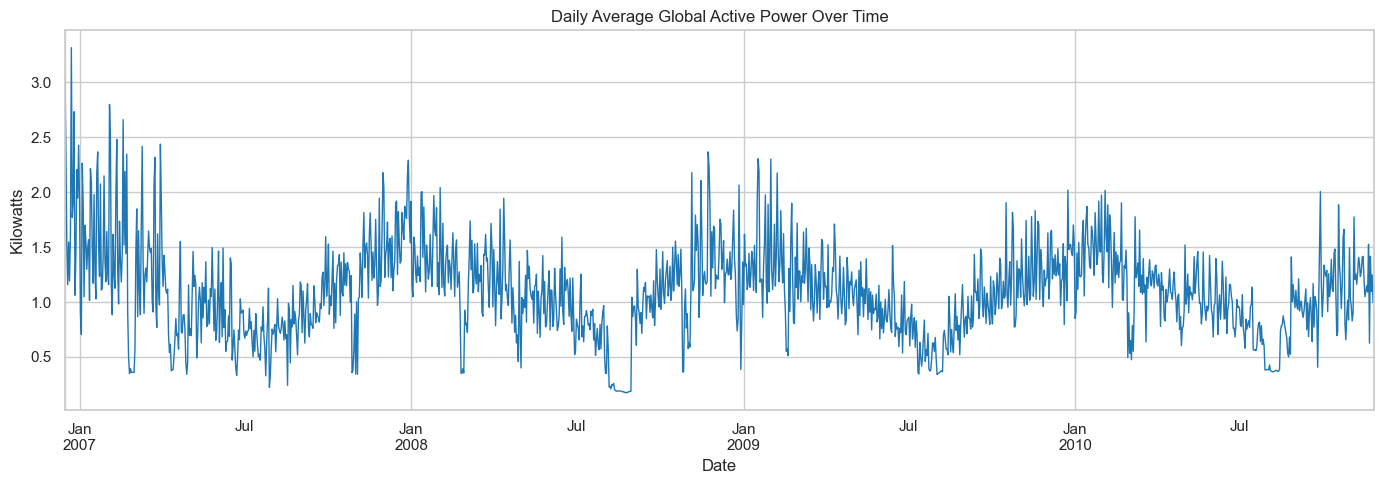

In [6]:

daily_power = power_df['Global_active_power'].resample('D').mean().dropna()
hourly_power = power_df['Global_active_power'].resample('h').mean().dropna()

fig, ax = plt.subplots(figsize=(14, 5))
daily_power.plot(ax=ax, color='#1f77b4', linewidth=1)
ax.set_title('Daily Average Global Active Power Over Time')
ax.set_xlabel('Date')
ax.set_ylabel('Kilowatts')
plt.tight_layout()
plt.show()


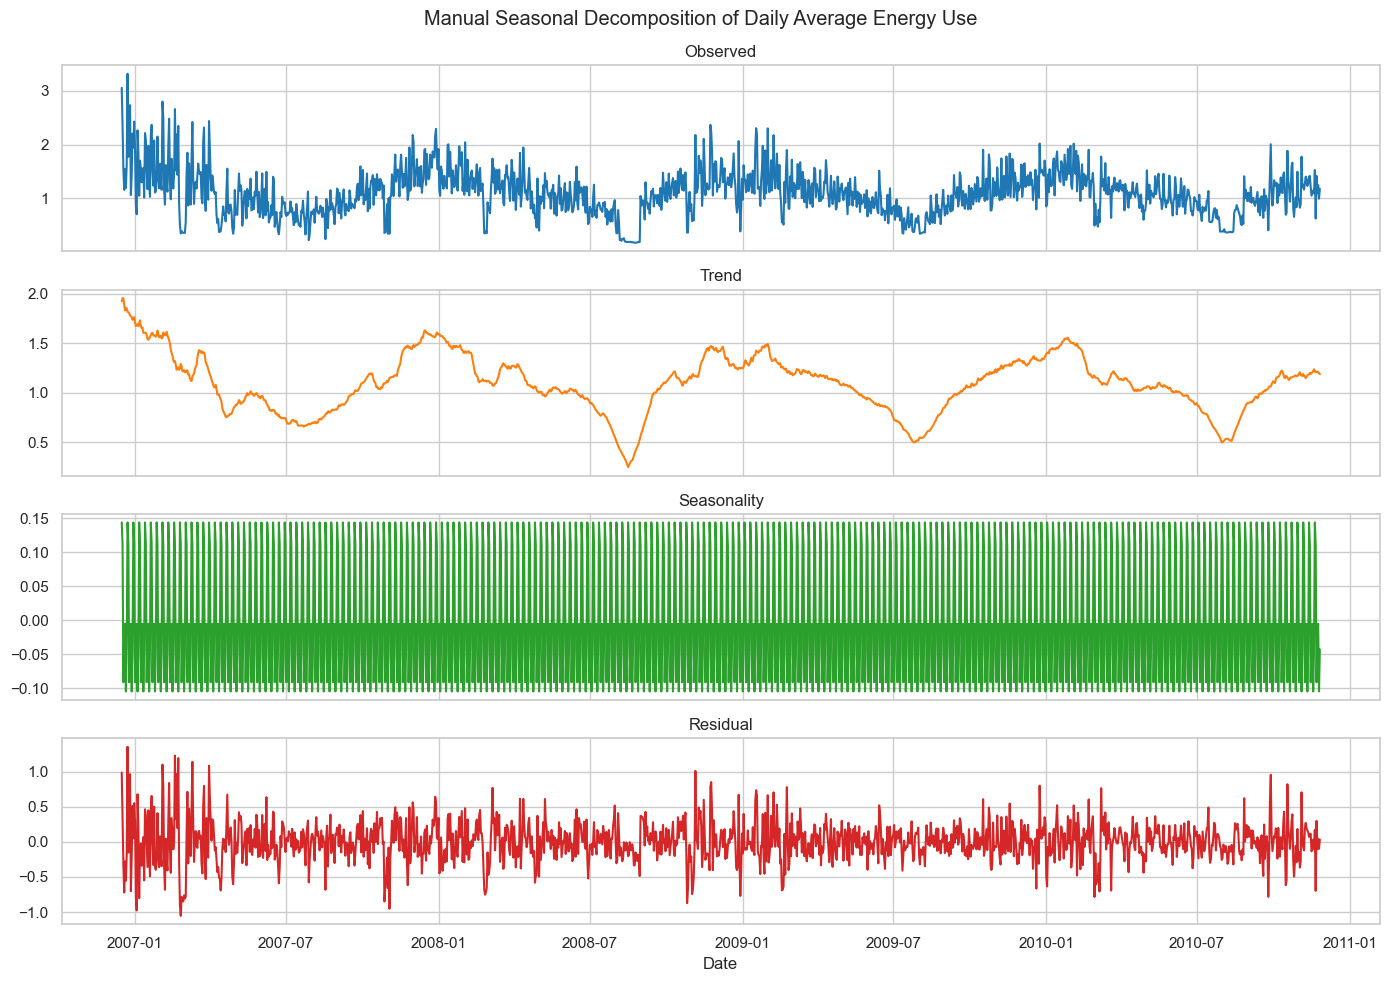

In [7]:
trend_component = daily_power.rolling(window=30, center=True, min_periods=15).mean()
detrended = daily_power - trend_component
seasonal_component = detrended.groupby(daily_power.index.dayofweek).transform('mean')
residual_component = daily_power - trend_component - seasonal_component

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
axes[0].plot(daily_power.index, daily_power, color='#1f77b4')
axes[0].set_title('Observed')

axes[1].plot(trend_component.index, trend_component, color='#ff7f0e')
axes[1].set_title('Trend')

axes[2].plot(seasonal_component.index, seasonal_component, color='#2ca02c')
axes[2].set_title('Seasonality')

axes[3].plot(residual_component.index, residual_component, color='#d62728')
axes[3].set_title('Residual')
axes[3].set_xlabel('Date')

fig.suptitle('Manual Seasonal Decomposition of Daily Average Energy Use', y=0.98)
plt.tight_layout()
plt.show()


The decomposition separates the signal into:

- `Trend`: the long-run direction of energy use over time.
- `Seasonality`: repeating weekly patterns in household behavior.
- `Residual`: irregular movements that may reflect unusual consumption, measurement noise, or operational exceptions.


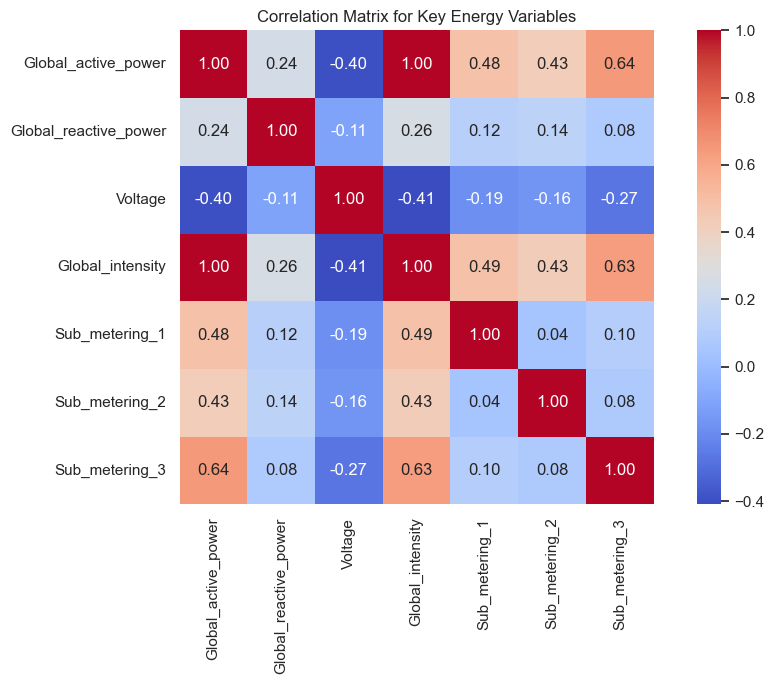

In [8]:

eda_sample = power_df.sample(n=50000, random_state=RANDOM_STATE)

corr_cols = [
    'Global_active_power', 'Global_reactive_power', 'Voltage',
    'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3'
]

corr_matrix = eda_sample[corr_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Matrix for Key Energy Variables')
plt.tight_layout()
plt.show()


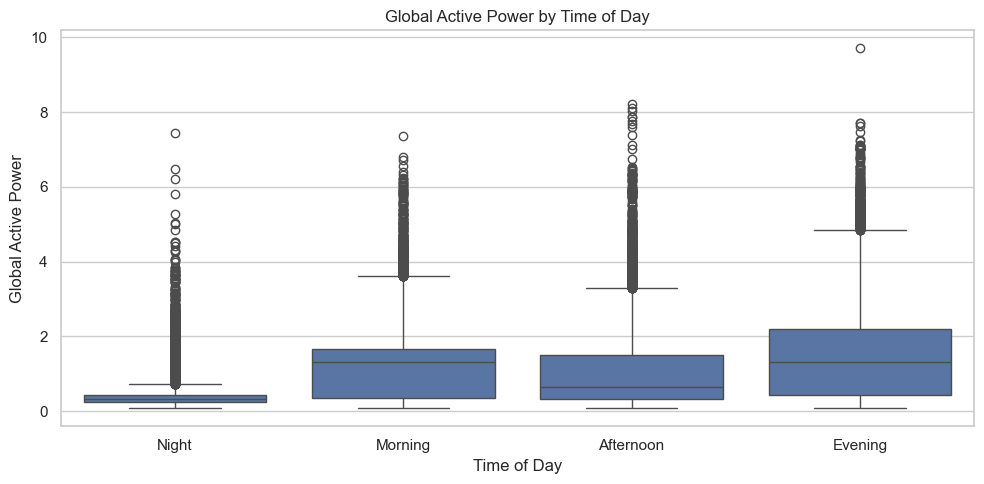

In [9]:

plt.figure(figsize=(10, 5))
sns.boxplot(data=eda_sample, x='Time_of_Day', y='Global_active_power', order=['Night', 'Morning', 'Afternoon', 'Evening'])
plt.title('Global Active Power by Time of Day')
plt.xlabel('Time of Day')
plt.ylabel('Global Active Power')
plt.tight_layout()
plt.show()



## 5. Statistical Sampling for a Representative Modeling Set
To connect this work to quality-assurance practice, I use **stratified sampling** by season so the training data reflects winter, spring, summer, and fall demand behavior. This matters because energy usage patterns are not uniform across the year, and it is similar to the way a risk analyst would make sure exception testing is representative across customer segments or time periods.


In [10]:

season_counts = power_df['Season'].value_counts().sort_index()
season_counts


Season
Fall      518223
Spring    529920
Summer    529920
Winter    497196
Name: count, dtype: int64


## 6. Algorithm 1: Isolation Forest for Anomaly Detection

### Why Isolation Forest?
Isolation Forest is designed specifically for anomaly detection. Instead of learning a standard average pattern and then measuring error, it isolates unusual observations by repeatedly splitting the feature space. Points that are easier to isolate are more likely to be anomalous.

### Analyst angle
- **Utility / EPRI framing:** suspicious meter readings, potential energy theft, or sensor failures can be triaged automatically instead of relying only on manual review.
- **Financial / JPMC framing:** the same logic mirrors automated screening for high-risk KYC exceptions or unusual operational records.

Because this dataset does not include labeled fraud events, I evaluate the model using a **proxy test**: I inject realistic synthetic anomalies into a holdout set and measure how often the model recovers them.


In [11]:

anomaly_features = [
    'Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity',
    'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'Is_Weekend', 'Hour'
]

anomaly_parts = []
for season, group in power_df.groupby('Season'):
    anomaly_parts.append(group.sample(n=min(8000, len(group)), random_state=RANDOM_STATE))

anomaly_df = pd.concat(anomaly_parts).sort_index()
train_anom_df, eval_anom_df = train_test_split(
    anomaly_df,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=anomaly_df['Season']
)

X_anom_train = train_anom_df[anomaly_features].copy()
X_anom_eval = eval_anom_df[anomaly_features].copy()

rng = np.random.default_rng(RANDOM_STATE)
synthetic_anomalies = X_anom_eval.copy()
synthetic_anomalies['Global_active_power'] *= rng.uniform(1.7, 2.8, len(synthetic_anomalies))
synthetic_anomalies['Global_intensity'] *= rng.uniform(1.4, 2.3, len(synthetic_anomalies))
synthetic_anomalies['Voltage'] *= rng.uniform(0.84, 0.95, len(synthetic_anomalies))
synthetic_anomalies['Sub_metering_3'] *= rng.uniform(1.3, 2.0, len(synthetic_anomalies))

X_proxy = pd.concat([X_anom_eval, synthetic_anomalies], ignore_index=True)
y_proxy = np.array([0] * len(X_anom_eval) + [1] * len(synthetic_anomalies))

iso_eval = IsolationForest(
    n_estimators=150,
    contamination=0.20,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
iso_eval.fit(X_anom_train)
proxy_predictions = (iso_eval.predict(X_proxy) == -1).astype(int)

iso_recall = recall_score(y_proxy, proxy_predictions)
iso_precision = precision_score(y_proxy, proxy_predictions)
iso_f1 = f1_score(y_proxy, proxy_predictions)

pd.DataFrame({
    'Metric': ['Detection Rate (Recall)', 'Precision', 'F1 Score'],
    'Isolation Forest': [round(iso_recall, 3), round(iso_precision, 3), round(iso_f1, 3)]
})


,Metric,Isolation Forest
0,Detection Rate (Recall),0.933
1,Precision,0.822
2,F1 Score,0.874


In [12]:

real_iso = IsolationForest(
    n_estimators=150,
    contamination=0.02,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
real_anomaly_sample = anomaly_df.copy()
real_anomaly_sample['Anomaly_Flag'] = (real_iso.fit_predict(real_anomaly_sample[anomaly_features]) == -1).astype(int)

flag_rate = real_anomaly_sample['Anomaly_Flag'].mean()
print(f"Share of sampled records flagged as suspicious: {flag_rate:.2%}")
real_anomaly_sample['Anomaly_Flag'].value_counts()


Share of sampled records flagged as suspicious: 2.00%


Anomaly_Flag
0    31360
1      640
Name: count, dtype: int64

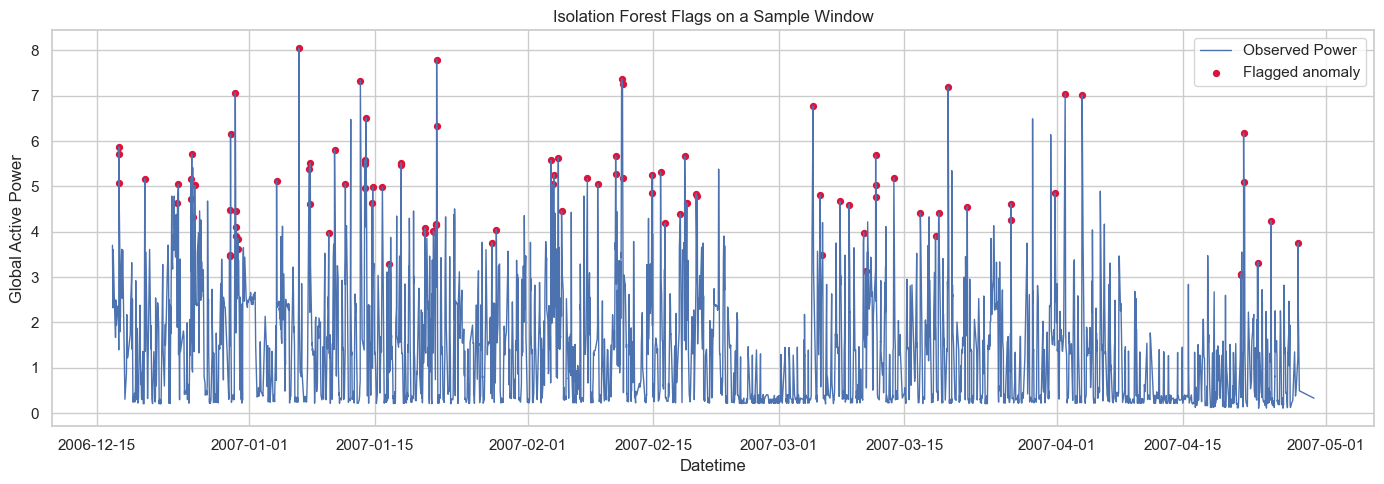

In [13]:

plot_sample = real_anomaly_sample[['Global_active_power', 'Anomaly_Flag']].sort_index().iloc[:3000]

plt.figure(figsize=(14, 5))
plt.plot(plot_sample.index, plot_sample['Global_active_power'], label='Observed Power', linewidth=1)
plt.scatter(
    plot_sample.index[plot_sample['Anomaly_Flag'] == 1],
    plot_sample.loc[plot_sample['Anomaly_Flag'] == 1, 'Global_active_power'],
    color='crimson', s=18, label='Flagged anomaly'
)
plt.title('Isolation Forest Flags on a Sample Window')
plt.xlabel('Datetime')
plt.ylabel('Global Active Power')
plt.legend()
plt.tight_layout()
plt.show()



## 7. Algorithm 2: Random Forest Regressor for Predictive Load Modeling

### Why Random Forest Regressor?
Random Forest is a strong choice when energy behavior is non-linear and relationships between variables are not captured well by a straight line. It can model interactions across voltage, intensity, sub-meter readings, and calendar features without heavy manual tuning.

### Analyst angle
- **EPRI framing:** predictive load modeling supports better supply planning and faster identification of abnormal demand behavior.
- **Operational-risk framing:** the same technique can estimate expected values and highlight exceptions when observed activity deviates from the model.

In this notebook, the regressor estimates `Global_active_power` from related meter signals and time-based features. That makes it a strong QA benchmark for expected load behavior. A production-grade future forecasting model could extend this design with lagged features, weather, tariffs, and holiday effects.


In [14]:

rf_parts = []
for season, group in power_df.groupby('Season'):
    rf_parts.append(group.sample(n=min(15000, len(group)), random_state=RANDOM_STATE))

rf_df = pd.concat(rf_parts).copy()

rf_features = [
    'Global_reactive_power', 'Voltage', 'Global_intensity',
    'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3',
    'Is_Weekend', 'Hour', 'DayOfWeek', 'Month', 'Time_of_Day', 'Season'
]

X_rf = pd.get_dummies(rf_df[rf_features], drop_first=True)
y_rf = rf_df['Global_active_power']

X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf,
    y_rf,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=rf_df['Season']
)

rf_model = RandomForestRegressor(
    n_estimators=80,
    max_depth=20,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_model.fit(X_train_rf, y_train_rf)
rf_predictions = rf_model.predict(X_test_rf)

rf_r2 = r2_score(y_test_rf, rf_predictions)
rf_mae = mean_absolute_error(y_test_rf, rf_predictions)
rf_rmse = mean_squared_error(y_test_rf, rf_predictions) ** 0.5

pd.DataFrame({
    'Metric': ['R^2', 'MAE', 'RMSE'],
    'Random Forest': [round(rf_r2, 4), round(rf_mae, 4), round(rf_rmse, 4)]
})


,Metric,Random Forest
0,R^2,0.9989
1,MAE,0.0193
2,RMSE,0.0346


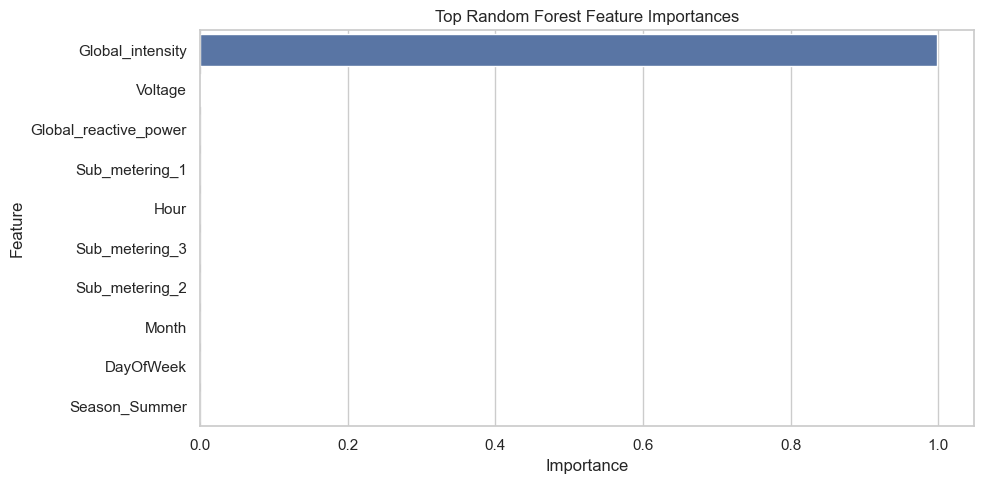

In [15]:

feature_importance = (
    pd.Series(rf_model.feature_importances_, index=X_rf.columns)
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
sns.barplot(x=feature_importance.values, y=feature_importance.index, color='#4c72b0')
plt.title('Top Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()



The very high `R^2` score should be interpreted carefully. Variables such as `Global_intensity` and the sub-meter readings are physically related to `Global_active_power`, so the model is learning a strong operational relationship rather than solving a difficult long-horizon forecast problem. That is still useful in a QA framework because it helps estimate what a reasonable reading should look like and then identify deviations from that expected pattern.



## 8. Results Summary
The table below organizes the results in the business-facing format requested by the project brief.


In [16]:

results_table = pd.DataFrame({
    'Metric': ['Accuracy / Score', 'Business Value', 'QA Impact'],
    'Isolation Forest (Outliers)': [
        f'{iso_recall:.1%} detection rate',
        'Identifies suspicious meter behavior, metering errors, or potential energy theft.',
        'Reduces manual exception review by automatically prioritizing unusual records.'
    ],
    'Random Forest (Prediction)': [
        f'{rf_r2:.3f} R^2 score',
        'Estimates expected load behavior for planning and control monitoring.',
        'Supports resource allocation by quantifying normal vs. abnormal operating patterns.'
    ]
})
results_table


,Metric,Isolation Forest (Outliers),Random Forest (Prediction)
0,Accuracy / Score,93.3% detection rate,0.999 R^2 score
1,Business Value,"Identifies suspicious meter behavior, metering...",Estimates expected load behavior for planning ...
2,QA Impact,Reduces manual exception review by automatical...,Supports resource allocation by quantifying no...



## 9. Observations and Analysis

### Did the models perform as expected?
Yes, with an important distinction:

- The **Isolation Forest** performed strongly on the proxy anomaly test, recovering most injected abnormal patterns. That suggests the feature set is informative for screening suspicious activity.
- The **Random Forest Regressor** achieved an extremely strong fit because the meter variables are closely connected to active power. In practice, that makes it useful for expected-value benchmarking and exception detection.

### What do the results mean operationally?
- A utility team could use the anomaly model to surface readings that deserve manual investigation before billing or grid-planning decisions are made.
- A financial-controls team could use the same pipeline logic to isolate unusual operational records, similar to KYC or transaction-monitoring exceptions.
- The combined workflow supports a broader **Digital Transformation (DX)** story: moving from manual review and meter inspection to automated, data-driven controls.

### Potential improvements
- Add weather, holidays, and tariff information for a truer future load-forecasting use case.
- Compare Isolation Forest with Local Outlier Factor or One-Class SVM.
- Create lagged forecasting targets such as 15-minute-ahead or 1-hour-ahead demand.
- Validate anomaly alerts with domain labels if real fraud or meter-failure tags become available.



## 10. Conclusion
This project built a complete machine learning pipeline for **financial and operational risk detection in utility infrastructure**. Starting from a raw text file, I converted the data into a clean time series, handled missing values with linear interpolation, engineered interpretable features, and applied both unsupervised and supervised machine learning.

From a business perspective, the project demonstrates:

- **Statistical Sampling** through stratified seasonal sampling to keep the modeling data representative.
- A practical anomaly-detection workflow for identifying suspicious energy usage and meter-quality issues.
- A predictive benchmarking model that estimates expected load behavior and helps explain deviations.
- A clear **Digital Transformation (DX)** narrative by replacing manual review with automated AI-driven insights.

Overall, the results show that machine learning can improve data quality monitoring, reduce manual review effort, and support more reliable decision-making in both utility and operational-risk settings.


## 11. Acknowledgment
This notebook was refined with the help of AI tools for organizing topics and improving overall structure. All interpretations, conclusions, and final judgments are my own.


## 12. References

Hebrail, G., & Berard, A. (2006). *Individual Household Electric Power Consumption* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C58K54

pandas developers. (2025). *pandas.DataFrame.interpolate*. pandas documentation. https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.interpolate.html

scikit-learn developers. (2025). *IsolationForest*. scikit-learn documentation. https://scikit-learn.org/1.5/modules/generated/sklearn.ensemble.IsolationForest.html

scikit-learn developers. (2025). *RandomForestRegressor*. scikit-learn documentation. https://scikit-learn.org/1.5/modules/generated/sklearn.ensemble.RandomForestRegressor.html
